# C. elegans Connectome Analysis

C. elegans is a roundworm whose neural connectome has been rigorously studied over the last several decades (see [https://wormwiring.org/](https://wormwiring.org/) for more details). Here we apply the method of conditional clique homology to evaluate the topology induced by the prescribed functional neuron classification of [Cook et al.](https://www.nature.com/articles/s41586-019-1352-7) (2019).

## Methods

Connectomics data and functional neuron classifications were obtained from the Emmons Laboratory WormWiring database (wormwiring.org) version 1.1 (April 18, 2020), as described in Cook et al.

**this is where we talk about what specific data model we are actually analyzing*

## Analysis

In [19]:
import numpy as np
import sys

# Prevent output truncation
np.set_printoptions(threshold=sys.maxsize)

from matplotlib import pyplot as plt
import networkit as nk

from clique_homology.stats_engine.stats_engine import StatsEngine
from c_elegans_colors import c_elegans_colors
from c_elegans_edges import c_elegans_edges

In [5]:
# import edges and functional groupings
edges = c_elegans_edges()
neurons, integer_labels, groups = c_elegans_colors()

# show edges data
print("Edges (head):", [edge for edge in edges[:5]])
# show group data
print("Neuron Groupings (head):", [group for group in groups[:5]])

Edges (head): [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]
Neuron Groupings (head): [0, 0, 0, 0, 0]


### Convert to a Networkit Graph

In [6]:
# initialize networkit Graph object
number_of_nodes = len(neurons)
G = nk.Graph(number_of_nodes, weighted=False, directed=False)

# add edges to the graph
for node1, node2 in edges:
    G.addEdge(node1, node2)

# self-loops are disallowed
G.removeSelfLoops()

### Compute Conditional Clique Homology

In [10]:
SE = StatsEngine(
    G=G,
    labels=[str(group) for group in groups]
)

In [11]:
n = 2000
p, obsD2, nullD2 = SE.pval(iters=n)
print("quantile:", p)
print("Mahalanobis distance of the observed grouping:", obsD2)
print("Average Mahalanobis distance:", sum(nullD2) / n)

[[ 7.52331356e+01 -1.38651831e+01  4.81705353e-01  2.27613807e-04
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-1.38651831e+01  1.79098569e+02 -2.08476513e+00 -1.13669335e-02
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 4.81705353e-01 -2.08476513e+00  1.53407679e+00  2.22736368e-03
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 2.27613807e-04 -1.13669335e-02  2.22736368e-03  2.49499750e-03
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.0000000

### Results

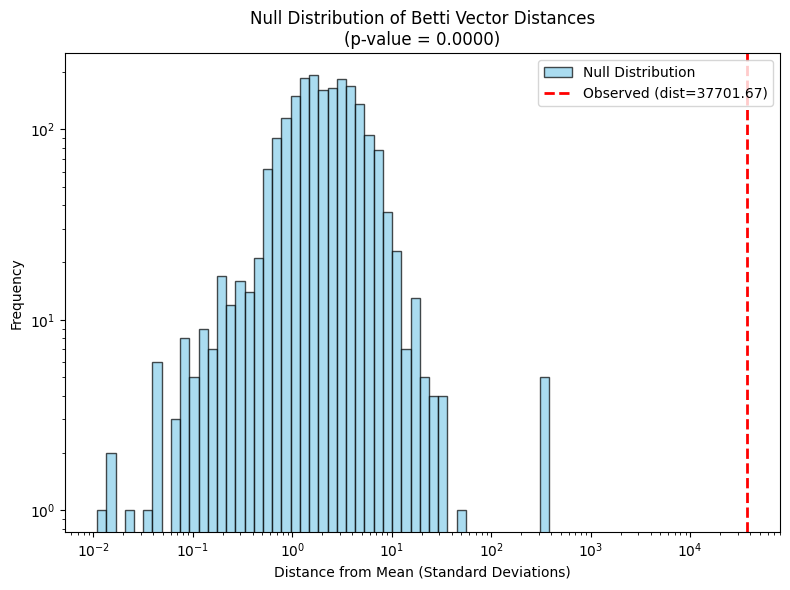

In [12]:
from clique_homology.stats_engine.visualization import plot_null_distribution
plot_null_distribution(nullD2, obsD2, p)

In [13]:
SE.observed_betti()

array([135,  96,  31,  10,   0,   0,   0,   0,   0])

In [21]:
SE.null_betti[:10, :]

array([[145,  94,   1,   0,   0,   0,   0,   0,   0],
       [120, 109,   1,   0,   0,   0,   0,   0,   0],
       [121, 107,   1,   0,   0,   0,   0,   0,   0],
       [128, 128,   0,   0,   0,   0,   0,   0,   0],
       [126, 120,   1,   0,   0,   0,   0,   0,   0],
       [127, 109,   0,   0,   0,   0,   0,   0,   0],
       [125, 114,   0,   0,   0,   0,   0,   0,   0],
       [127,  95,   0,   0,   0,   0,   0,   0,   0],
       [119, 114,   0,   0,   0,   0,   0,   0,   0],
       [115, 117,   1,   0,   0,   0,   0,   0,   0]])